In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}   # once, at the top of the notebook

# Inputs
temp = [360]

# --- Load CSVs ---
df_sex   = pd.read_csv('sex_tot.csv')
df_s2tot = pd.read_csv('s2_tot.csv')
df_iawps = pd.read_csv('iapws_sex_kb.csv')   # IAPWS reference (one value per (rho, T))

# Strip whitespace from headers (the files have a leading space before column names)
for d in (df_sex, df_s2tot, df_iawps):
    d.columns = d.columns.str.strip()


In [ ]:
# --- filter by temperature, then collapse replicates -> mean/std per density ---
def aggregate(df, temps, label, valcol='thermoValue'):
    x = df.copy()
    x['Density']     = pd.to_numeric(x['Density'],     errors='coerce')
    x['Temperature'] = pd.to_numeric(x['Temperature'], errors='coerce')
    x = x[x['Temperature'].isin(temps)]
    return (
        x.groupby('Density', as_index=False)
         .agg(**{f'{label}_mean': (valcol, 'mean'),
                 f'{label}_std':  (valcol, 'std'),
                 f'{label}_n':    (valcol, 'count')})
         .sort_values('Density')
         .reset_index(drop=True)
    )


sex_agg   = aggregate(df_sex,   temp, 'sex')
s2tot_agg = aggregate(df_s2tot, temp, 's2tot')
iawps_agg = aggregate(df_iawps, temp, 'iawps')   # one row per density at this T; std will be NaN

# Stays quiet unless the replicate count varies between densities
for label, a in (('sex', sex_agg), ('s2tot', s2tot_agg)):
    counts = a[f'{label}_n']
    if counts.nunique() > 1:
        print(f'{label}: replicate counts vary from {counts.min()} to {counts.max()} across densities')


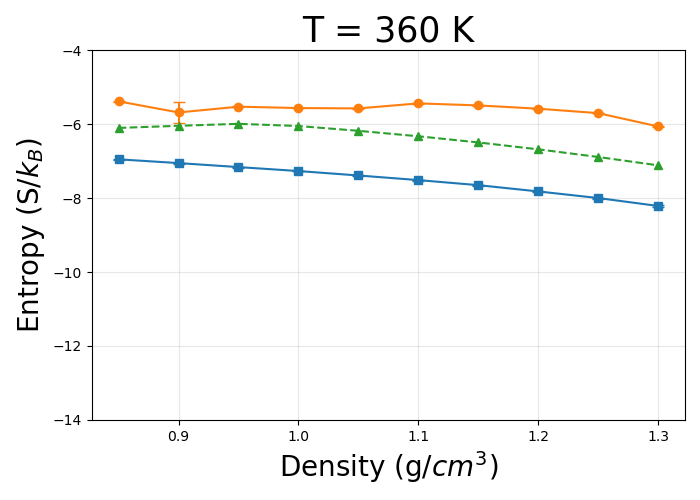

In [8]:
# --- Plot S_ex and S_2 (total) with error bars ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    sex_agg['Density'], sex_agg['sex_mean'],
    yerr=sex_agg['sex_std'],
    fmt='s-', capsize=4, label='$S_{ex}$'
)

ax.errorbar(
    s2tot_agg['Density'], s2tot_agg['s2tot_mean'],
    yerr=s2tot_agg['s2tot_std'],
    fmt='o-', capsize=4, label='$S_2$'
)

# IAPWS reference: one value per density, so std is all NaN.
iawps_yerr = iawps_agg['iawps_std'] if iawps_agg['iawps_std'].notna().any() else None
ax.errorbar(
    iawps_agg['Density'], iawps_agg['iawps_mean'],
    yerr=iawps_yerr,
    fmt='^--', capsize=4, label='$S_{ex}$ (IAPWS)'
)

ax.set_xlabel('Density (g/$cm^3$)', fontsize=20)
ax.set_ylabel('Entropy (S/$k_B$)', fontsize=20)
ax.yaxis.set_label_position('left')
ax.yaxis.tick_left()

#ax.set_title(f'T = {temp[0]} K', fontsize=25)
ax.grid(True, which='both', alpha=0.3)
#ax.legend(loc='lower right')

ax.set_ylim(-14, -4)   # F7
ax.tick_params(axis='y', which='both', labelleft=True)
ax.tick_params(axis='x', which='both', labelbottom=True)


fig.tight_layout()
# fig.savefig(f'sex_vs_s2_{temp[0]}K.png', dpi=300)

#fig, ax = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(left=0.16, right=0.97, bottom=0.14, top=0.95)
plt.show()
